In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("mall_dataset.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
X = df.iloc[:, [3,4]].values

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

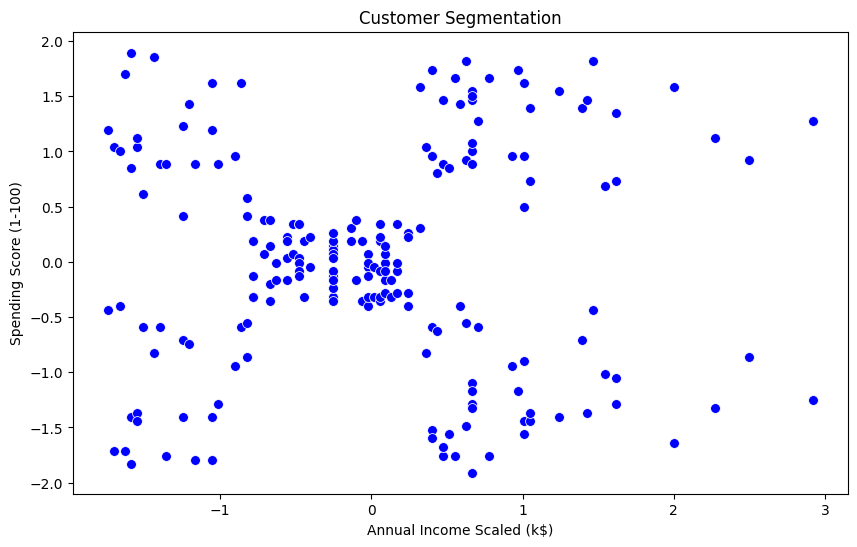

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(x = X_scaled[:, 0], y  = X_scaled[:, 1],c = 'blue', s = 50)
plt.xlabel('Annual Income Scaled (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation')
plt.show()



In [6]:
model = KMeans(n_clusters=5, random_state=42)
model.fit(X_scaled)

df['Cluster'] = model.fit_predict(X_scaled)
df


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [7]:
# replacing the cluster labels with the original scale values for better visualization
df.replace({'Cluster': {0: 'Low Income, Low Spending',
                        1: 'High Income, High Spending',
                        2: 'High Income, Low Spending',
                        3: 'Low Income, High Spending',
                        4: 'Average Income, Average Spending'}}, inplace=True)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,"Average Income, Average Spending"
1,2,Male,21,15,81,"High Income, Low Spending"
2,3,Female,20,16,6,"Average Income, Average Spending"
3,4,Female,23,16,77,"High Income, Low Spending"
4,5,Female,31,17,40,"Average Income, Average Spending"
...,...,...,...,...,...,...
195,196,Female,35,120,79,"High Income, High Spending"
196,197,Female,45,126,28,"Low Income, High Spending"
197,198,Male,32,126,74,"High Income, High Spending"
198,199,Male,32,137,18,"Low Income, High Spending"


Cluster Centers: [[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


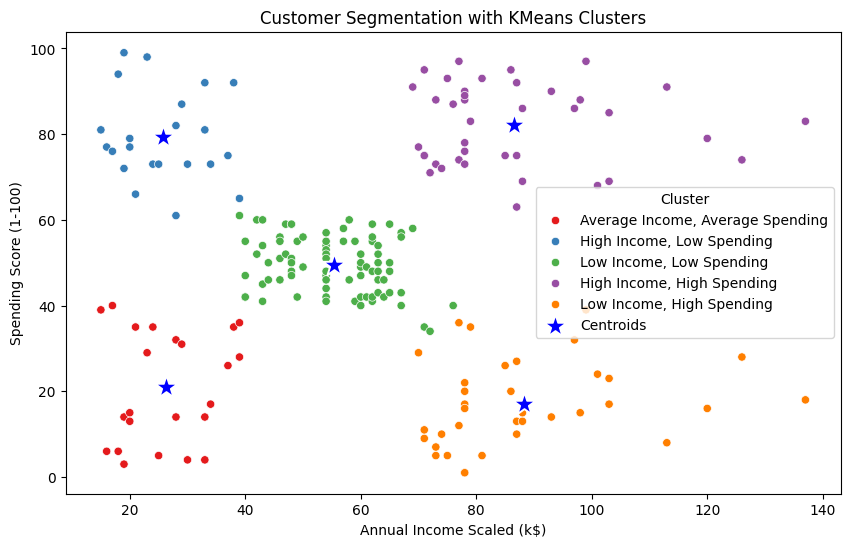

In [12]:
# Cluster centers in the original scale
print(f"Cluster Centers: {model.cluster_centers_}")
# Kmeans grouping visualization
centroids = scaler.inverse_transform(model.cluster_centers_)
plt.figure(figsize=(10,6))
sns.scatterplot(x = X[:, 0], y  = X[:, 1], hue = df['Cluster'], palette = 'Set1')
sns.scatterplot(x = centroids[:, 0], y = centroids[:, 1], marker='*', s=300, color='blue', label='Centroids')
plt.xlabel('Annual Income Scaled (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation with KMeans Clusters')
plt.legend(title='Cluster')
plt.show()